# Flower Classification

### *Part II — Computer Vision Task: Image Classification with CNN*

<br>

| | |
|---|---|
| **Module** | 6CS012 Artificial Intelligence |
| **Task** | Image Classification using Convolutional Neural Networks |
| **Project Type** | Collaborative Portfolio Project |
| **Student** | Isha Bhatta |
| **Student ID** | 2408180 |
| **Group** | L6CG1 |

---
# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

### Dataset Description

The dataset consists of flower images from **five classes**: Daisy, Dandelion, Rose, Sunflower, and Tulip — organised into class-specific directories.

| Attribute | Detail |
|---|---|
| **Task Type** | Supervised Learning |
| **Problem Category** | Multi-class Image Classification |
| **Input** | RGB Flower Images |
| **Output** | Predicted Flower Class Label |

## 1. Data Understanding, Analysis, Visualization and Cleaning

In [ ]:
# File and path handling
import os
from pathlib import Path

# Image processing
import cv2
from PIL import Image

# Numerical operations
import numpy as np
import random
import math

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning and neural networks
import tensorflow as tf
from tensorflow.keras import layers, models

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Pretrained model
from tensorflow.keras.applications import VGG16

# Optimizer
from tensorflow.keras.optimizers import Adam

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# define paths to the dataset directories
DATASET_PATH = Path('/content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower Classification')
MODELS_PATH = DATASET_PATH.parent /


os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

train_path = DATASET_PATH / "Train"
test_path = DATASET_PATH / "Test"

try:
    print("Dataset root contents:", os.listdir(DATASET_PATH))
    print("Train folder contents:", os.listdir(train_path))
    print("Test folder contents:", os.listdir(test_path))
except FileNotFoundError as e:
    print(f"Error: One or more dataset directories not found: {e}")
except Exception as e:
    print(f"An unexpected error occurred while listing directory contents: {e}")

Dataset root contents: ['Train', 'Test']
Train folder contents: ['rose', 'sunflower', 'daisy', 'dandelion', 'tulip']
Test folder contents: ['38287568_627de6ca20.jpg', '110472418_87b6a3aa98_m.jpg', '15207766_fc2f1d692c_n.jpg', '27465811_9477c9d044.jpg', '8475769_3dea463364_m.jpg']


In [ ]:
def save_plot(fig, filename):
    """
    Saves a matplotlib figure to the FIGURES_PATH directory.
    Args:
        fig (matplotlib.figure.Figure): The figure object to save.
        filename (str): The name of the file to save the figure as.
    """
    full_path = os.path.join(FIGURES_PATH, filename)
    try:
        fig.savefig(full_path)
        print(f"Plot saved to: {full_path}")
    except Exception as e:
        print(f"Error saving plot to {full_path}: {e}")

### Dataset Statistics

Class names are loaded from the training directory structure. Image counts and class proportions are computed for each of the five flower categories.

In [ ]:
# get class names from subdirectories within the training path
class_names = sorted([
    folder.name for folder in train_path.iterdir()
    if folder.is_dir()
])

print("\nDetected Classes:")
for cls in class_names:
    print(cls)

print("\nTotal Classes:", len(class_names))


Detected Classes:
daisy
dandelion
rose
sunflower
tulip

Total Classes: 5


In [ ]:
# define valid image file extensions
valid_extensions = ('.jpg', '.jpeg', '.png')
train_counts = {}

# iterate through each class directory in the training set
for cls in class_names:
    class_dir = train_path / cls
    # count images with valid extensions
    images = [f for f in os.listdir(class_dir)
              if f.lower().endswith(valid_extensions)]
    train_counts[cls] = len(images)

# calculate total number of training images
total_train = sum(train_counts.values())

print("\nClass Distribution:\n")
# print image counts and percentages for each class
for cls in class_names:
    count = train_counts[cls]
    pct = (count / total_train) * 100
    print(f"{cls:<12}: {count:4d} images ({pct:5.1f}%)")

print(f"\nTotal Images: {total_train}")


Class Distribution:

daisy       :  756 images ( 17.7%)
dandelion   : 1044 images ( 24.4%)
rose        :  776 images ( 18.1%)
sunflower   :  725 images ( 17.0%)
tulip       :  976 images ( 22.8%)

Total Images: 4277


### Class Imbalance Check

A bar chart visualises the distribution of images across classes. The imbalance ratio (max/min class count) is computed to assess whether the dataset is balanced.

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/class_distribution_training_set.png


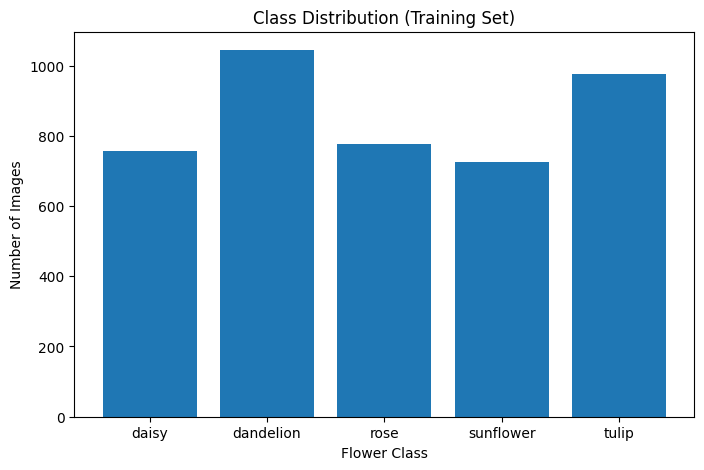

In [ ]:
# create a bar plot for class distribution in the training set
fig = plt.figure(figsize=(8, 5))
plt.bar(class_names, [train_counts[c] for c in class_names])
plt.title("Class Distribution (Training Set)")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
save_plot(fig, "class_distribution_training_set.png")
plt.show()

In [ ]:
# check for class imbalance by calculating max/min ratio
max_count = max(train_counts.values())
min_count = min(train_counts.values())
ratio = max_count / min_count

print(f"\nImbalance Ratio (max/min): {ratio:.2f}")

if ratio < 1.5:
    print("Dataset is relatively balanced.")
else:
    print("Dataset is imbalanced.")


Imbalance Ratio (max/min): 1.44
Dataset is relatively balanced.


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/sample_flower_images.png


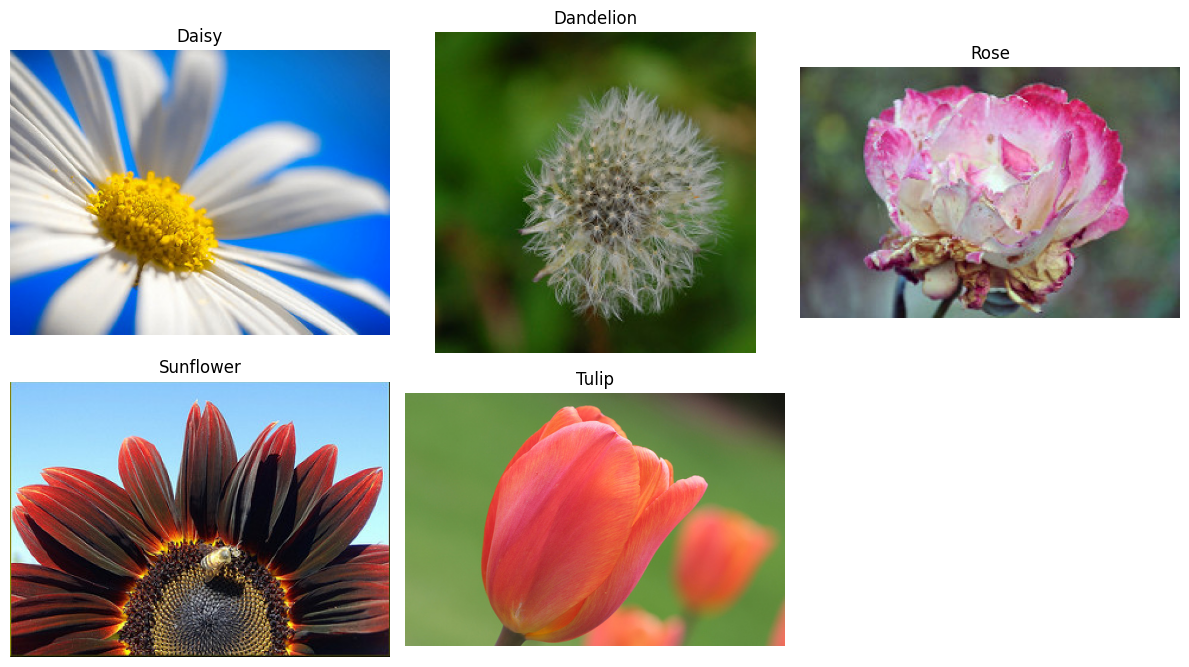

In [ ]:
# define columns and rows for the subplot grid
cols = 3
rows = math.ceil(len(class_names) / cols)

fig = plt.figure(figsize=(12, 7))

# iterate through each class to display a sample image
for i, cls in enumerate(class_names):

    plt.subplot(rows, cols, i + 1)

    # filter for valid image files
    images = [
        f for f in os.listdir(train_path / cls)
        if f.lower().endswith(valid_extensions)
    ]

    # select a random image from the class
    img_path = train_path / cls / random.choice(images)

    # read and convert image from bgr to rgb
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    # display the image with its class name as title
    plt.imshow(img)
    plt.title(cls.capitalize())
    plt.axis('off')

plt.tight_layout()
save_plot(fig, "sample_flower_images.png")
plt.show()

### Image Dimension Analysis

Up to 100 images per class are sampled to analyse height and width distributions.

In [ ]:
# list to store image dimensions (height, width)
image_sizes = []

# iterate through each class to sample image sizes
for cls in class_names:
    class_dir = train_path / cls

    images = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_extensions)
    ]

    # sample up to 100 images per class for analysis
    sample_images = images[:100]

    for img_name in sample_images:
        img_path = class_dir / img_name
        img = cv2.imread(str(img_path))

        # if image is loaded successfully, append its dimensions
        if img is not None:
            h, w = img.shape[:2]
            image_sizes.append((h, w))

print(f"Total images analysed: {len(image_sizes)}")

Total images analysed: 500


In [ ]:
# extract heights and widths from collected image sizes
heights = [s[0] for s in image_sizes]
widths = [s[1] for s in image_sizes]

# print statistics for image heights
print("Height Statistics")
print(f"Min: {min(heights)}")
print(f"Max: {max(heights)}")
print(f"Average: {int(np.mean(heights))}")

# print statistics for image widths
print("\nWidth Statistics")
print(f"Min: {min(widths)}")
print(f"Max: {max(widths)}")
print(f"Average: {int(np.mean(widths))}")

Height Statistics
Min: 119
Max: 414
Average: 255

Width Statistics
Min: 156
Max: 500
Average: 345


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/image_dimension_distribution.png


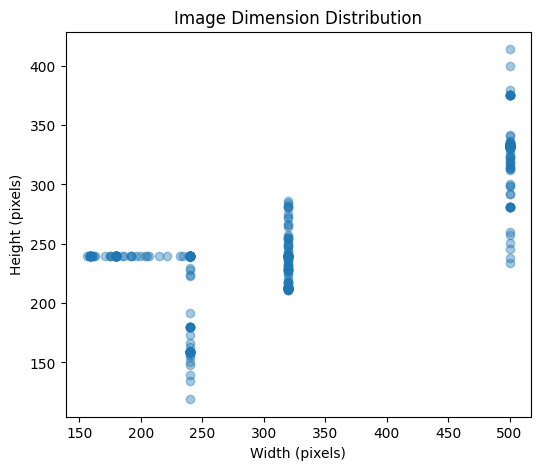

In [ ]:
# create a scatter plot of image dimensions
fig = plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.4)

plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Dimension Distribution")
save_plot(fig, "image_dimension_distribution.png")
plt.show()

**Findings:**
- Heights: **120 – 441 px** (avg ≈ 265 px)
- Widths: **134 – 1024 px** (avg ≈ 359 px)

Images are non-uniform in size. All images are resized to **224 × 224 px** to standardise inputs, retain sufficient visual detail, and align with pre-trained CNN architectures used in Part B.

### Data Cleaning

All training images are verified using PIL. Any corrupted files are detected and removed before preprocessing.

In [ ]:
# list to store paths of corrupted files
corrupt_files = []

# iterate through each class and check images for corruption
for cls in class_names:
    class_dir = train_path / cls

    for img_name in os.listdir(class_dir):
        img_path = class_dir / img_name

        try:
            img = Image.open(img_path)
            img.verify()  # attempts to load and verify the image file
        except:
            # if verification fails, add to corrupt_files list
            corrupt_files.append(img_path)

print("Corrupted images found:", len(corrupt_files))

Corrupted images found: 0


In [ ]:
# remove all identified corrupted image files
for file in corrupt_files:
    try:
        os.remove(file)
    except OSError as e:
        print(f"Error removing file {file}: {e}")

print("Corrupted images removed.")

Corrupted images removed.


## 2. Data Preprocessing

### Train–Validation Split Strategy

An **80:20 split** is used, handled via Keras `ImageDataGenerator` with `validation_split=0.2`. This maintains class balance across subsets without manual file reorganisation.

| Parameter | Value |
|---|---|
| Image Size | 224 × 224 px |
| Batch Size | 32 |
| Split Ratio | 80% Train / 20% Validation |
| Label Mode | Categorical (one-hot) |

### Data Loading & Normalisation

Datasets are loaded using `tf.keras.preprocessing.image_dataset_from_directory`. Pixel values are rescaled to **[0, 1]** using a `Rescaling(1./255)` layer, then cached and prefetched for training efficiency.

In [ ]:
# define image size and batch size for dataset loading
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

try:
    # create a tensorflow dataset for training images
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        label_mode='categorical'
    )

    # create a tensorflow dataset for validation images
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        label_mode='categorical'
    )

    # retrieve class names from the training dataset
    class_names = train_ds.class_names
    print(class_names)
except Exception as e:
    print(f"Error creating image datasets: {e}")
    # Set datasets to None or empty to prevent downstream errors if creation fails
    train_ds = None
    val_ds = None
    class_names = []

Found 4277 files belonging to 5 classes.
Using 3422 files for training.
Found 4277 files belonging to 5 classes.
Using 855 files for validation.
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [ ]:
# define a normalization layer to rescale pixel values to [0, 1]
normalization_layer = layers.Rescaling(1./255)

# apply normalization to both training and validation datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# cache and prefetch datasets for performance optimization
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

## 3. Baseline Model

### Model Architecture

A simple sequential CNN with three convolutional blocks followed by three dense layers.

| Layer Type | Config |
|---|---|
| Conv2D (×3) | 32 → 64 → 128 filters, 3×3, ReLU |
| MaxPooling2D (×3) | 2×2 |
| Dense (×3) | 256 → 128 → 64, ReLU |
| Output | 5 units, Softmax |

In [ ]:
# define the baseline cnn model architecture
baseline_cnn_model = tf.keras.Sequential([

    # feature extraction layers

    # first convolutional block: 32 filters, 3x3 kernel, relu activation. input images are 224x224x3.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)), # reduces spatial dimensions by half

    # second convolutional block: 64 filters, 3x3 kernel, relu activation
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # reduces spatial dimensions by half

    # third convolutional block: 128 filters, 3x3 kernel, relu activation
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # reduces spatial dimensions by half

    # flatten the 2d feature maps into a 1d vector for dense layers
    layers.Flatten(),

    # classifier (fully connected layers)

    layers.Dense(256, activation='relu'),  # first fully connected layer
    layers.Dense(128, activation='relu'),  # second fully connected layer
    layers.Dense(64, activation='relu'),   # third fully connected layer

    # output layer: 5 units for 5 flower classes, with softmax for probability distribution
    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# print a summary of the baseline cnn model architecture, including layer types, output shapes, and parameter counts
baseline_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,149 (85.01 MB)

 Trainable params: 22,286,149 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

> **Note:** The baseline CNN has approximately **22.2 million trainable parameters**. The high capacity relative to dataset size increases the risk of overfitting, which is addressed in subsequent sections.

### Compiling the Baseline CNN

| Setting | Value |
|---|---|
| Optimizer | Adam |
| Loss | Categorical Crossentropy |
| Metric | Accuracy |

In [ ]:
# compile the baseline cnn model
baseline_cnn_model.compile(
    optimizer='adam', # use adam optimizer
    loss='categorical_crossentropy', # use categorical crossentropy for multi-class classification with one-hot labels
    metrics=['accuracy'] # monitor accuracy during training
)

#### Training Configuration

The model is trained for **10 epochs** — sufficient to assess initial learning capability without extensive computation. Deeper training is reserved for subsequent model comparisons.

### Model Training

In [ ]:
import time

# record start time for training
start_time = time.time()

# train the baseline cnn model
history = baseline_cnn_model.fit(
    train_ds, # training dataset
    validation_data=val_ds, # validation dataset
    epochs=10, # number of training epochs
    verbose=1 # show training progress
)

# record end time and print total training duration
end_time = time.time()
print(f"\nTraining completed in {end_time - start_time:.2f} seconds")

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy: 0.4357 - loss: 1.2941 - val_accuracy: 0.5228 - val_loss: 1.1045
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.5891 - loss: 1.0082 - val_accuracy: 0.6058 - val_loss: 1.0015
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6666 - loss: 0.8493 - val_accuracy: 0.6667 - val_loss: 0.8817
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.7493 - loss: 0.6599 - val_accuracy: 0.6480 - val_loss: 1.0219
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8378 - loss: 0.4591 - val_accuracy: 0.6550 - val_loss: 1.1213
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8799 - loss: 0.3269 - val_accuracy: 0.6351 - val_loss: 1.3327
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9325 - loss: 0.1947 - val_accuracy: 0.6526 - val_loss: 1.7714
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9652 - loss: 0.1079 - val_ac

### Performance Evaluation

Training and validation accuracy/loss are plotted over epochs to assess convergence and detect overfitting.

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_accuracy_plot.png


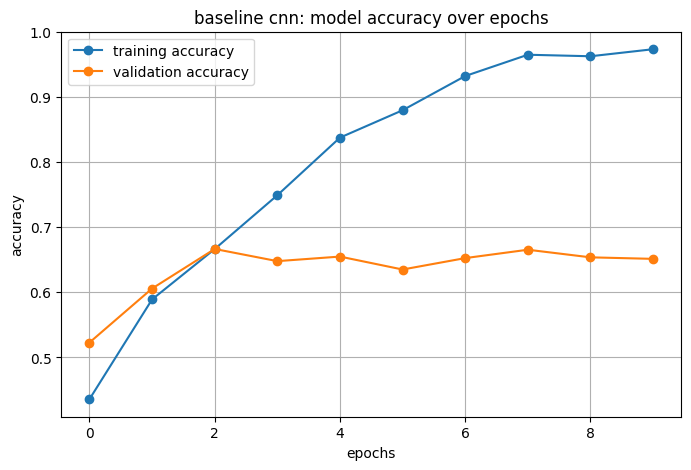

In [ ]:
# plot training and validation accuracy over epochs
fig = plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='training accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='validation accuracy', marker='o')

plt.title('baseline cnn: model accuracy over epochs')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
save_plot(fig, "baseline_cnn_accuracy_plot.png")
plt.show()

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_loss_plot.png


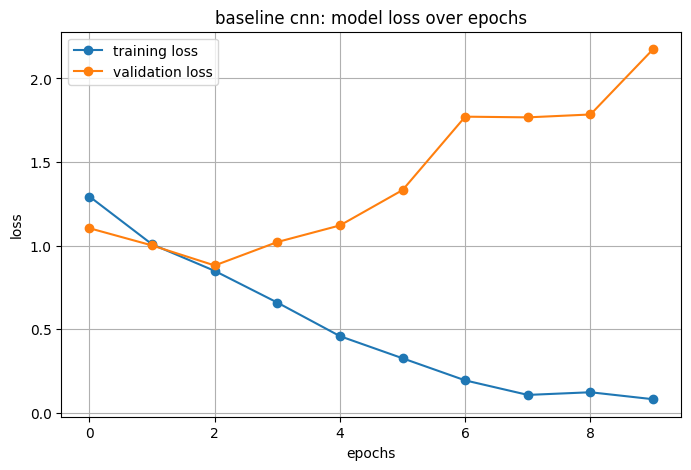

In [ ]:
# plot training and validation loss over epochs
fig = plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='training loss', marker='o')
plt.plot(history.history['val_loss'], label='validation loss', marker='o')

plt.title('baseline cnn: model loss over epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
save_plot(fig, "baseline_cnn_loss_plot.png")
plt.show()

In [ ]:
# evaluate the baseline cnn model on the validation dataset
loss, accuracy = baseline_cnn_model.evaluate(val_ds, verbose=1)
print(f"\nvalidation loss     : {loss:.4f}")
print(f"validation accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6515 - loss: 2.1746

validation loss     : 2.1746
validation accuracy : 0.6515 (65.15%)


In [ ]:
# initialize lists to store true and predicted labels
y_true_list, y_pred_list = [], []

# iterate through the validation dataset to collect predictions and true labels
for images, labels in val_ds:
    preds = baseline_cnn_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

# convert lists to numpy arrays
y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# print the classification report
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       daisy       0.52      0.77      0.62       142
   dandelion       0.82      0.69      0.75       210
        rose       0.50      0.63      0.55       139
   sunflower       0.74      0.76      0.75       156
       tulip       0.73      0.47      0.57       208

    accuracy                           0.65       855
   macro avg       0.66      0.66      0.65       855
weighted avg       0.68      0.65      0.65       855



Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_confusion_matrix.png


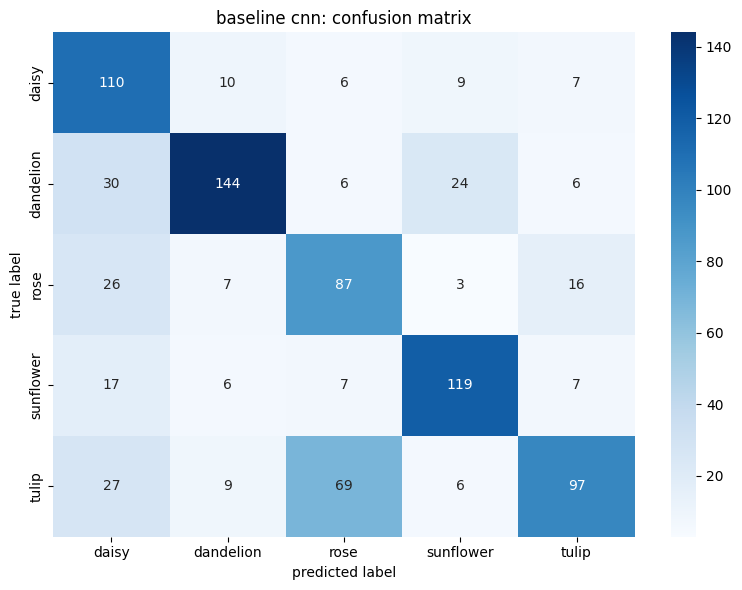

In [ ]:
# generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot the confusion matrix using seaborn heatmap
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("baseline cnn: confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.tight_layout()
save_plot(fig, "baseline_cnn_confusion_matrix.png")
plt.show()

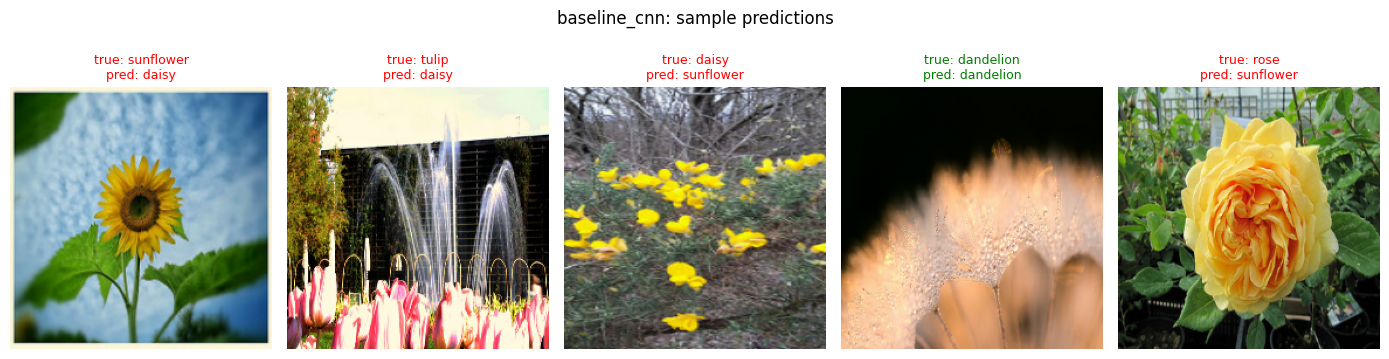

In [ ]:
# define a function to visualize sample predictions
def predict_and_show(model, dataset, class_labels, num_images=5, save_path=None, filename_prefix=""):
    # get a batch of images and labels from the dataset
    images, labels = next(iter(dataset))
    predictions = model.predict(images[:num_images], verbose=0)

    plt.figure(figsize=(14, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].numpy())

        true_label = class_labels[np.argmax(labels[i])]
        pred_label = class_labels[np.argmax(predictions[i])]
        color = "green" if true_label == pred_label else "red"

        plt.title(f"true: {true_label}\npred: {pred_label}", color=color, fontsize=9)
        plt.axis('off')

    plt.suptitle(f"{filename_prefix}: sample predictions", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(os.path.join(save_path, f"{filename_prefix}_sample_predictions.png"))
    plt.show()

# use the function to show predictions from the baseline model
predict_and_show(baseline_cnn_model, val_ds, class_names, save_path=FIGURES_PATH, filename_prefix="baseline_cnn")

In [ ]:
os.makedirs(MODELS_PATH, exist_ok=True)

# define full path for saving the baseline model
model_path = os.path.join(MODELS_PATH, "baseline_cnn_model.keras")

# save the trained baseline cnn model
baseline_cnn_model.save(model_path)
print("model saved at:", model_path)

model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/baseline_cnn_model.keras


### Baseline Model Performance Summary

| Metric | Value |
|---|---|
| Validation Accuracy | ~64% |
| Best Class (Recall) | Sunflower — 0.85 |
| Weakest Class (Recall) | Rose — 0.45 |

Training accuracy reached ~98% while validation accuracy plateaued at ~64%, indicating clear **overfitting**. The model struggles with visually similar classes such as Daisy, Tulip, and Dandelion. Regularisation and a deeper architecture are needed to improve generalisation.

## 4. Deeper Architecture with Regularisation

### Model Architecture

A deeper CNN with six convolutional blocks, Batch Normalisation, and Dropout regularisation. Data augmentation is applied during training.

| Component | Detail |
|---|---|
| Data Augmentation | Horizontal Flip, Rotation (10%), Zoom (10%) |
| Conv Blocks | 32 → 64 → 128 → 256 → 256 → 512 filters, 3×3, ReLU |
| Batch Normalisation | After each Conv block |
| Dense Layers | 512 → 256 → 128, ReLU |
| Dropout | 0.5, 0.4, 0.3 |
| Output | 5 units, Softmax |
| Early Stopping | Patience = 5 (monitors val_loss) |

In [ ]:
# define data augmentation layers to be applied during training
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"), # randomly flip images horizontally
    layers.RandomRotation(0.1),      # randomly rotate images by a factor of 0.1 (10% of 360 degrees)
    layers.RandomZoom(0.1),          # randomly zoom in/out on images by a factor of 0.1
], name="data_augmentation")

# define the deeper cnn model architecture with regularization
deeper_cnn_model = tf.keras.Sequential([

    # data augmentation layer (only active during training)
    data_augmentation,

    # feature extraction layers with batch normalization

    # block 1: 32 filters, 3x3 kernel, relu activation
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.BatchNormalization(), # normalizes activations of the previous layer
    layers.MaxPooling2D((2, 2)), # reduces spatial dimensions

    # block 2: 64 filters, 3x3 kernel, relu activation
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 3: 128 filters, 3x3 kernel, relu activation
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 4: 256 filters, 3x3 kernel, relu activation
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 5: 256 filters, 3x3 kernel, relu activation
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # block 6: 512 filters, 3x3 kernel, relu activation
    layers.Conv2D(512, (3, 3), activation='relu'),
    layers.BatchNormalization(),

    # flatten the 2d feature maps into a 1d vector
    layers.Flatten(),

    # classifier (fully connected layers with dropout)
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # dropout for regularization

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # output layer: 5 units for 5 flower classes, with softmax activation
    layers.Dense(5, activation='softmax')
])

deeper_cnn_model.build(input_shape=(None, 224, 224, 3))

# print a summary of the deeper cnn model architecture
deeper_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,32

 Total params: 4,688,325 (17.88 MB)

 Trainable params: 4,685,829 (17.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [ ]:
# define early stopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss', # monitor validation loss
    patience=5, # stop if validation loss doesn't improve for 5 epochs
    restore_best_weights=True, # restore model weights from the epoch with the best validation loss
    verbose=1
)

# define model checkpoint callback to save the best model during training
checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'deeper_cnn_best.keras'),
    monitor='val_loss', # monitor validation loss
    save_best_only=True, # save only the model with the best validation loss
    verbose=1
)

#### Compiling the Model

| Setting | Value |
|---|---|
| Optimizer | Adam |
| Loss | Categorical Crossentropy |
| Metric | Accuracy |

In [ ]:
# compile the deeper cnn model
deeper_cnn_model.compile(
    optimizer='adam', # use adam optimizer
    loss='categorical_crossentropy', # use categorical crossentropy loss
    metrics=['accuracy'] # monitor accuracy
)

### Model Training

Trained for up to **30 epochs** with Early Stopping (patience=5) and ModelCheckpoint to save the best weights.

In [ ]:
# record start time for training
import time

start_time = time.time()

# train the deeper cnn model with defined callbacks
history_deep = deeper_cnn_model.fit(
    train_ds, # training dataset
    validation_data=val_ds, # validation dataset
    epochs=30, # maximum number of training epochs
    callbacks=[early_stop, checkpoint], # apply early stopping and model checkpoint
    verbose=1 # show training progress
)

# record end time and print total training duration
end_time = time.time()
print(f"deep model training time: {end_time - start_time:.2f} seconds")

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3083 - loss: 2.3434
Epoch 1: val_loss improved from None to 1.92780, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - accuracy: 0.3381 - loss: 2.1082 - val_accuracy: 0.2456 - val_loss: 1.9278
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.4119 - loss: 1.6559
Epoch 2: val_loss improved from 1.92780 to 1.58356, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.4255 - loss: 1.5297 - val_accuracy: 0.2491 - val_loss: 1.5836
Epoch 3/30
10

### Performance Evaluation

Accuracy and loss curves are plotted for both training and validation sets to monitor convergence and regularisation effectiveness.

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_accuracy_plot.png


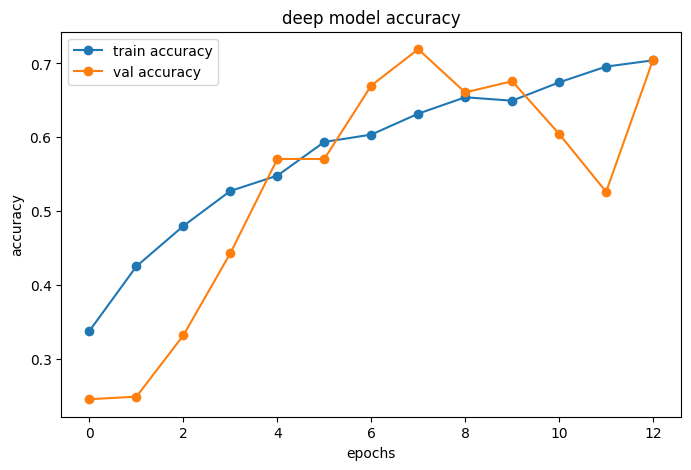

In [ ]:
# plot training and validation accuracy for the deeper model
fig = plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['accuracy'], label='train accuracy', marker='o')
plt.plot(history_deep.history['val_accuracy'], label='val accuracy', marker='o')

plt.title("deep model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
save_plot(fig, "deeper_cnn_accuracy_plot.png")
plt.show()

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_loss_plot.png


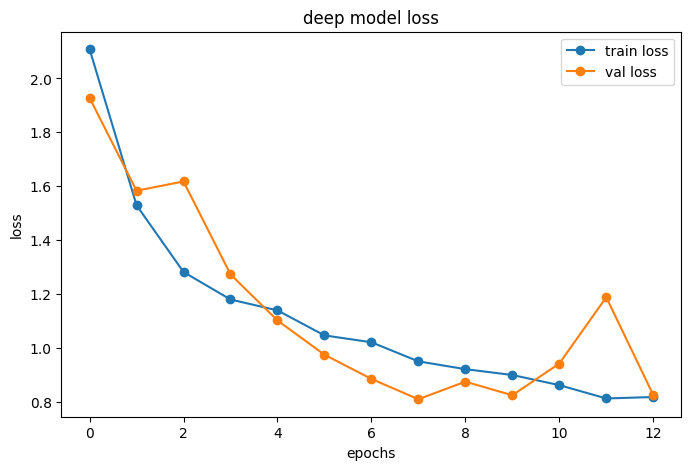

In [ ]:
# plot training and validation loss for the deeper model
fig = plt.figure(figsize=(8, 5))
plt.plot(history_deep.history['loss'], label='train loss', marker='o')
plt.plot(history_deep.history['val_loss'], label='val loss', marker='o')

plt.title("deep model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
save_plot(fig, "deeper_cnn_loss_plot.png")
plt.show()

In [ ]:
# evaluate the deeper cnn model on the validation dataset
loss, accuracy = deeper_cnn_model.evaluate(val_ds, verbose=1)
print(f"\nvalidation loss     : {loss:.4f}")
print(f"validation accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7193 - loss: 0.8104

validation loss     : 0.8104
validation accuracy : 0.7193 (71.93%)


In [ ]:
# initialize lists to store true and predicted labels for the deeper model
y_true_list, y_pred_list = [], []

# iterate through the validation dataset to collect predictions and true labels
for images, labels in val_ds:
    preds = deeper_cnn_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

# convert lists to numpy arrays
y_true_deep = np.array(y_true_list)
y_pred_deep = np.array(y_pred_list)

# print the classification report for the deeper model
print(classification_report(y_true_deep, y_pred_deep, target_names=class_names))

              precision    recall  f1-score   support

       daisy       0.89      0.58      0.70       142
   dandelion       0.75      0.86      0.80       210
        rose       0.49      0.72      0.58       139
   sunflower       0.83      0.81      0.82       156
       tulip       0.76      0.61      0.68       208

    accuracy                           0.72       855
   macro avg       0.74      0.71      0.72       855
weighted avg       0.75      0.72      0.72       855



Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_confusion_matrix.png


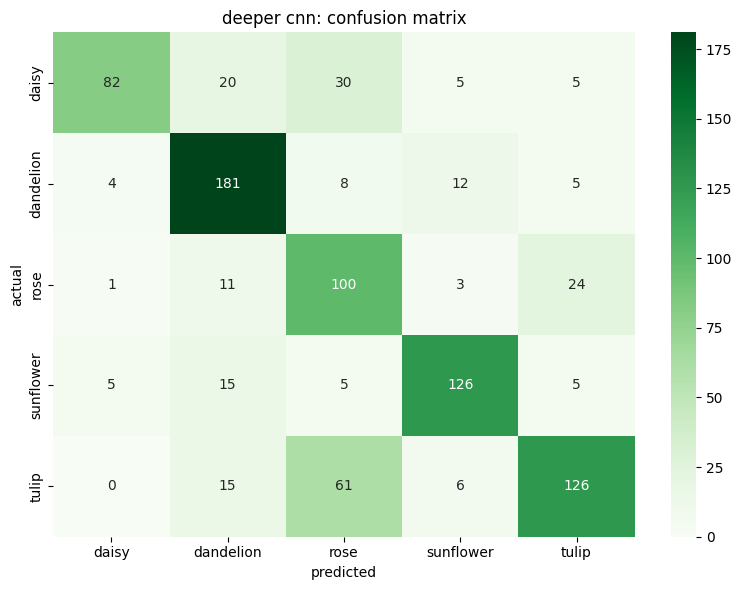

In [ ]:
# generate the confusion matrix for the deeper model
cm = confusion_matrix(y_true_deep, y_pred_deep)

# plot the confusion matrix using seaborn heatmap
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("deeper cnn: confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.tight_layout()
save_plot(fig, "deeper_cnn_confusion_matrix.png")
plt.show()

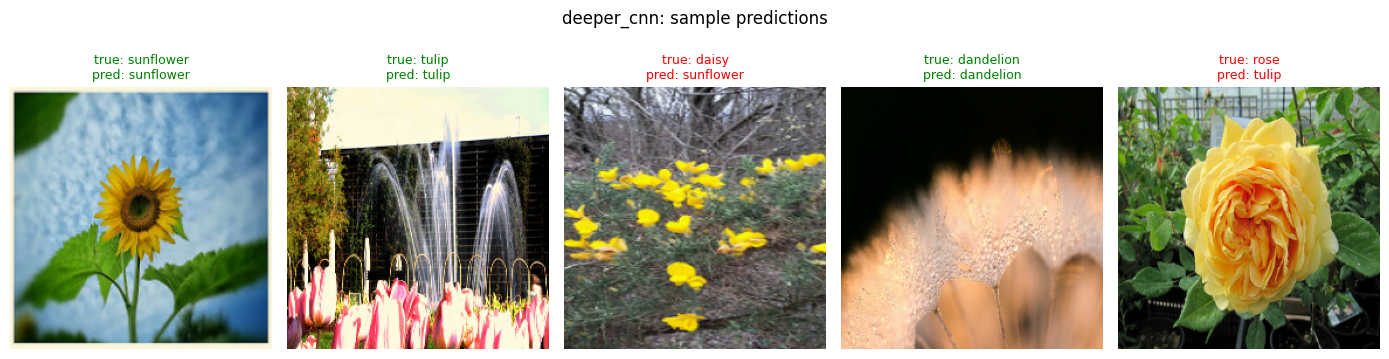

In [ ]:
# use the predict_and_show function to visualize sample predictions from the deeper model
predict_and_show(deeper_cnn_model, val_ds, class_names, save_path=FIGURES_PATH, filename_prefix="deeper_cnn")

## 5. Experimentation and Comparative Analysis

### Classification Report: Baseline vs. Deeper CNN

#### Baseline CNN
```
              precision    recall  f1-score   support

       daisy       0.57      0.61      0.59       142
   dandelion       0.65      0.76      0.70       210
        rose       0.55      0.53      0.54       139
   sunflower       0.82      0.62      0.70       156
       tulip       0.64      0.63      0.64       208

    accuracy                           0.64       855
   macro avg       0.64      0.63      0.63       855
weighted avg       0.65      0.64      0.64       855
```

#### Deeper CNN
```
              precision    recall  f1-score   support

       daisy       0.80      0.71      0.75       142
   dandelion       0.83      0.74      0.78       210
        rose       0.46      0.81      0.58       139
   sunflower       0.87      0.76      0.81       156
       tulip       0.78      0.61      0.69       208

    accuracy                           0.72       855
   macro avg       0.75      0.72      0.72       855
weighted avg       0.76      0.72      0.73       855
```

The deeper model improves overall accuracy from **64% → 72%** and shows consistent gains in precision and F1-score across most classes. The Rose class trades lower precision for a significantly higher recall (0.53 → 0.81), indicating it identifies more true positives but with more false positives — likely due to visual overlap with other classes.

### Summary of Experiments Conducted

The following experiments were carried out to assess model behaviour:

1. **Baseline vs. Deeper Model** — Accuracy, loss, and evaluation metrics compared.
2. **Computational Efficiency** — Training time and parameter cost analysed.
3. **Optimizer Comparison** — SGD vs. Adam on the deeper architecture.
4. **Ablation Study** — Dropout removed to evaluate its individual impact.
5. **Challenges and Observations** — Overfitting, hardware, and training time discussed.

### Computational Efficiency: Baseline vs. Deeper CNN

| Model | Training Time | Epochs |
|---|---|---|
| Baseline CNN | ~97.76 seconds | 10 |
| Deeper CNN (Adam) | ~340.63 seconds | 22 (early stopping) |
| Deeper CNN (SGD) | ~428.11 seconds | 30 |
| Deeper CNN (No Dropout) | ~343.83 seconds | 17 (early stopping) |

The deeper model takes significantly longer to train due to increased depth and regularisation components, but this cost is offset by improved generalisation.

In [ ]:
def build_deeper_cnn_architecture():
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = tf.keras.Sequential([
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),

        layers.Flatten(),

        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(5, activation='softmax')
    ])

    model.build(input_shape=(None, 224, 224, 3))
    return model


def train_evaluate_and_save(
    model,
    optimizer_name,
    optimizer_instance,
    epochs,
    train_ds,
    val_ds,
    class_names,
    model_suffix="",
    patience=5
):

    model.summary()

    # Define early stopping callback
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    # Define model checkpoint callback
    checkpoint = ModelCheckpoint(
        os.path.join(MODELS_PATH, f'deeper_cnn_{model_suffix}_best.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # Compile the model
    model.compile(
        optimizer=optimizer_instance,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Record start time for training
    start_time = time.time()

    # Train the model
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # Record end time and print total training duration
    end_time = time.time()
    print(f"\nDeep model ({optimizer_name}) training time: {end_time - start_time:.2f} seconds")

    # Plot training and validation accuracy
    fig_acc = plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='train accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='val accuracy', marker='o')
    plt.title(f"Deeper Model ({optimizer_name}): Model Accuracy Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    save_plot(fig_acc, f"deeper_cnn_{model_suffix}_accuracy_plot.png")
    plt.show()

    # Plot training and validation loss
    fig_loss = plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='train loss', marker='o')
    plt.plot(history.history['val_loss'], label='val loss', marker='o')
    plt.title(f"Deeper Model ({optimizer_name}): Model Loss Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    save_plot(fig_loss, f"deeper_cnn_{model_suffix}_loss_plot.png")
    plt.show()

    # Evaluate on validation dataset
    loss, accuracy = model.evaluate(val_ds, verbose=1)
    print(f"\nValidation Loss ({optimizer_name})     : {loss:.4f}")
    print(f"Validation Accuracy ({optimizer_name}) : {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Classification Report
    y_true_list, y_pred_list = [], []
    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(np.argmax(labels.numpy(), axis=1))
    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    print(f"\nClassification Report (Deeper CNN with {optimizer_name}):\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig_cm = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"Deeper CNN ({optimizer_name}): Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    save_plot(fig_cm, f"deeper_cnn_{model_suffix}_confusion_matrix.png")
    plt.show()

    predict_and_show(model, val_ds, class_names, save_path=FIGURES_PATH, filename_prefix=f"deeper_cnn_{model_suffix}")

    model_path = os.path.join(MODELS_PATH, f"deeper_cnn_{model_suffix}_model.keras")
    model.save(model_path)
    print(f"\n{optimizer_name}-trained model saved at: {model_path}")

    return history, loss, accuracy, y_true, y_pred

#### Training Deeper Model with SGD Optimizer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,32

 Total params: 4,688,325 (17.88 MB)

 Trainable params: 4,685,829 (17.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.2272 - loss: 2.4172
Epoch 1: val_loss improved from None to 1.59682, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.2539 - loss: 2.1788 - val_accuracy: 0.2456 - val_loss: 1.5968
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3256 - loss: 1.8154
Epoch 2: val_loss did not improve from 1.59682
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - accuracy: 0.3384 - loss: 1.7538 - val_accuracy: 0.2456 - val_loss: 1.6368
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.3564 - loss: 1.6915
Epoch 3: val_loss improved from 1.59682 to 1.58515, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_best

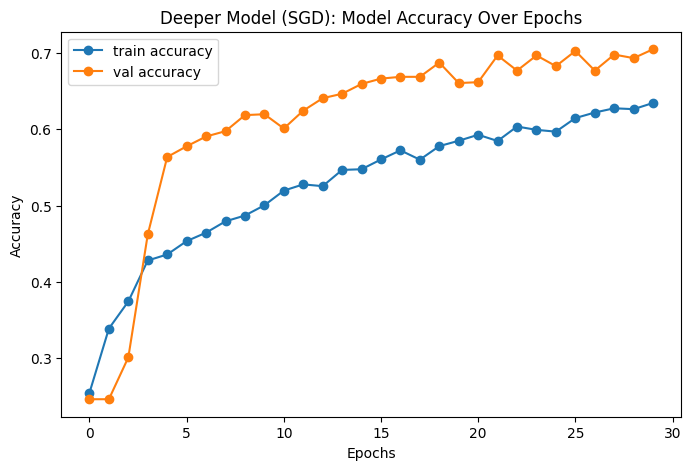

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_sgd_loss_plot.png


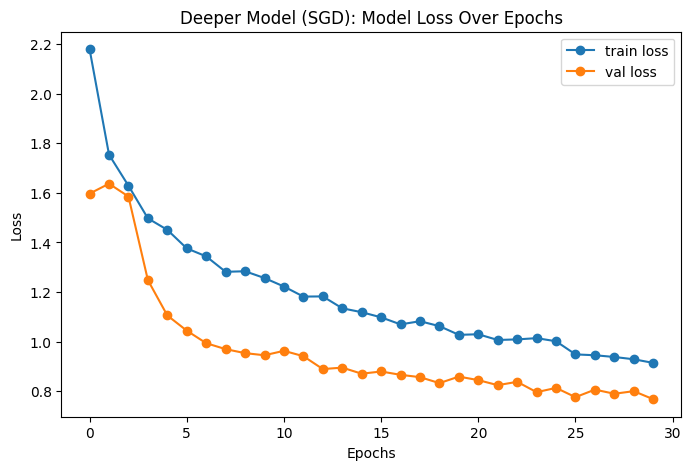

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7053 - loss: 0.7682

Validation Loss (SGD)     : 0.7682
Validation Accuracy (SGD) : 0.7053 (70.53%)

Classification Report (Deeper CNN with SGD):

              precision    recall  f1-score   support

       daisy       0.73      0.75      0.74       142
   dandelion       0.77      0.72      0.74       210
        rose       0.59      0.60      0.60       139
   sunflower       0.68      0.87      0.76       156
       tulip       0.75      0.60      0.67       208

    accuracy                           0.71       855
   macro avg       0.70      0.71      0.70       855
weighted avg       0.71      0.71      0.70       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_sgd_confusion_matrix.png


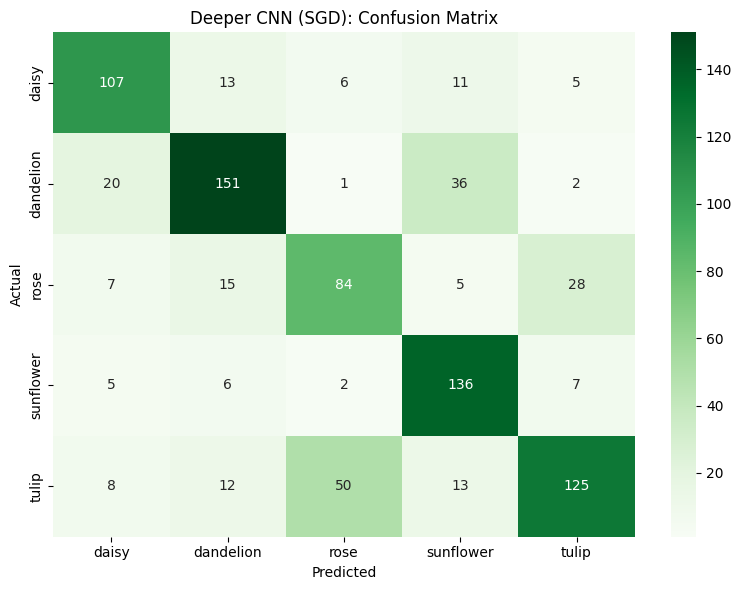

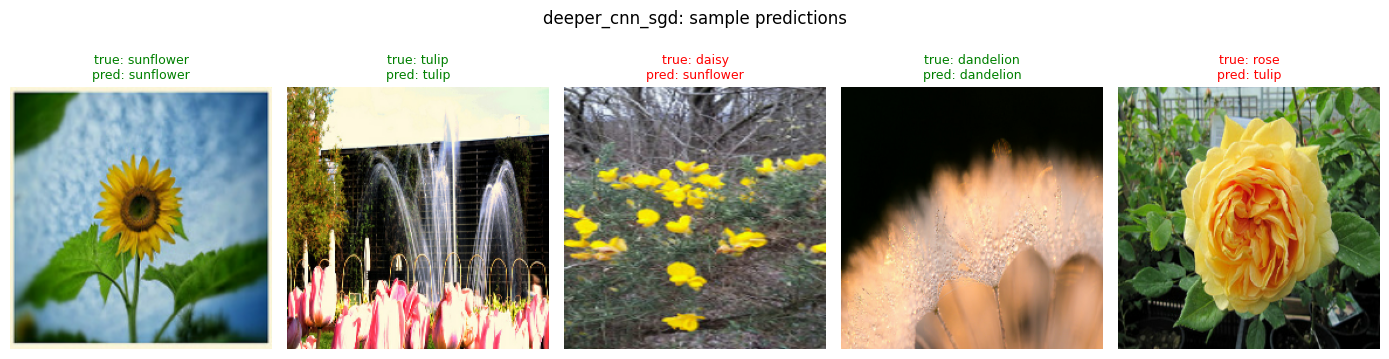


SGD-trained model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_sgd_model.keras


In [ ]:
from tensorflow.keras.optimizers import SGD
import time

deep_model_sgd = build_deeper_cnn_architecture()

sgd_optimizer = SGD(learning_rate=0.001)

history_sgd, loss_sgd, accuracy_sgd, y_true_sgd, y_pred_sgd = train_evaluate_and_save(
    model=deep_model_sgd,
    optimizer_name='SGD',
    optimizer_instance=sgd_optimizer,
    epochs=30,
    train_ds=train_ds,
    val_ds=val_ds,
    class_names=class_names,
    model_suffix='sgd'
)

### Optimizer Analysis: SGD vs. Adam

| Metric | Adam | SGD |
|---|---|---|
| Validation Accuracy | ~71.70% | ~69.47% |
| Validation Loss | ~0.7553 | ~0.7917 |
| Training Time | ~340.63 s | ~428.11 s |

**Adam** outperformed SGD in both accuracy and convergence speed. SGD requires additional tuning (e.g., learning rate schedules) to achieve comparable results. For this dataset and architecture, Adam is the more effective choice.

In [ ]:
def build_deeper_cnn_no_dropout_architecture():
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    model = tf.keras.Sequential([
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),

        layers.Flatten(),

        layers.Dense(512, activation='relu'),
        # Dropout layers are removed

        layers.Dense(256, activation='relu'),
        # Dropout layers are removed

        layers.Dense(128, activation='relu'),
        # Dropout layers are removed

        layers.Dense(5, activation='softmax')
    ])

    model.build(input_shape=(None, 224, 224, 3))
    return model

print("Deeper CNN architecture without dropout defined.")

Deeper CNN architecture without dropout defined.


#### Training Deeper Model without Dropout (Adam Optimizer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,89

 Total params: 4,688,325 (17.88 MB)

 Trainable params: 4,685,829 (17.88 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4244 - loss: 1.4994
Epoch 1: val_loss improved from None to 3.74246, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 146ms/step - accuracy: 0.4784 - loss: 1.3602 - val_accuracy: 0.2456 - val_loss: 3.7425
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5627 - loss: 1.1367
Epoch 2: val_loss improved from 3.74246 to 2.61439, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_best.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.5818 - loss

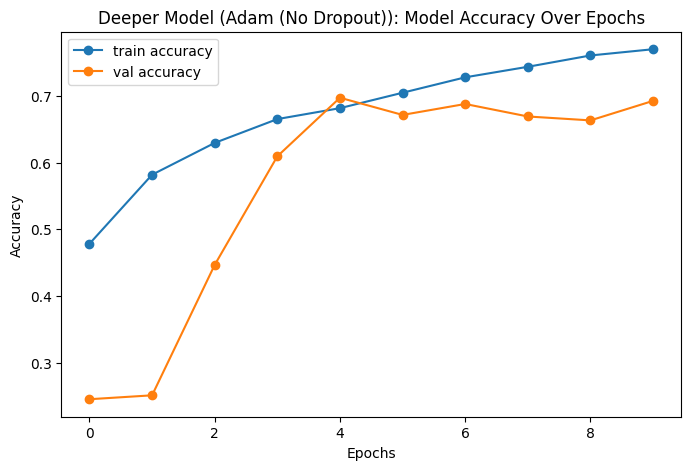

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_no_dropout_loss_plot.png


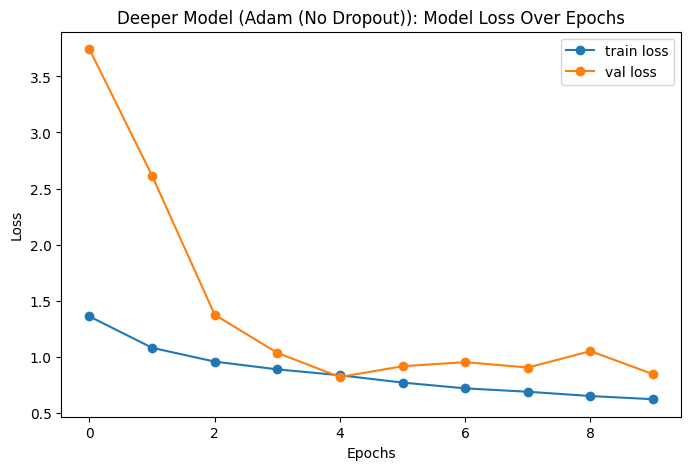

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6971 - loss: 0.8202

Validation Loss (Adam (No Dropout))     : 0.8202
Validation Accuracy (Adam (No Dropout)) : 0.6971 (69.71%)

Classification Report (Deeper CNN with Adam (No Dropout)):

              precision    recall  f1-score   support

       daisy       0.78      0.67      0.72       142
   dandelion       0.67      0.80      0.73       210
        rose       0.56      0.60      0.58       139
   sunflower       0.69      0.84      0.76       156
       tulip       0.84      0.57      0.68       208

    accuracy                           0.70       855
   macro avg       0.71      0.70      0.69       855
weighted avg       0.71      0.70      0.70       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_adam_no_dropout_confusion_matrix.png


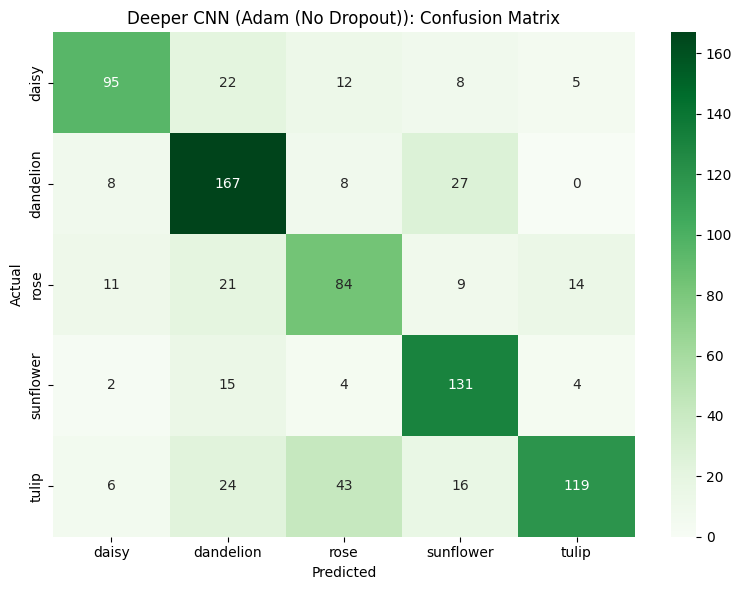

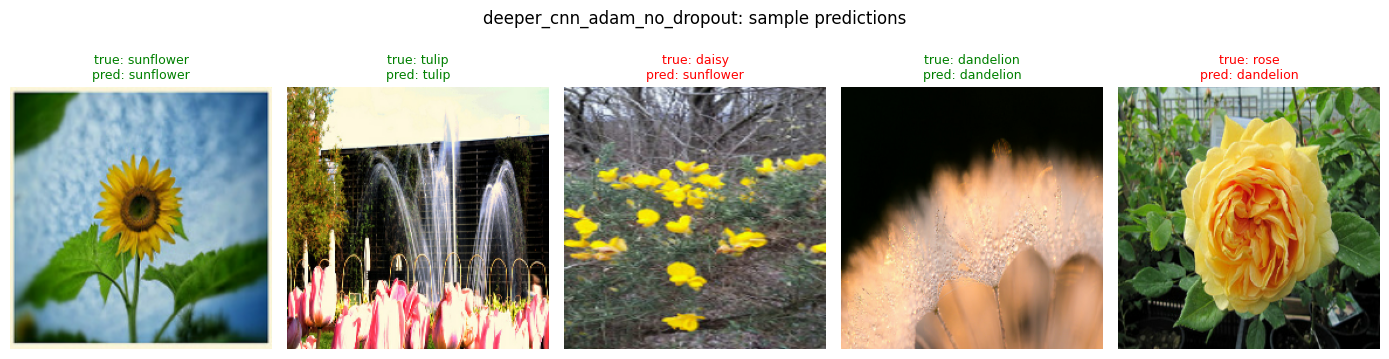


Adam (No Dropout)-trained model saved at: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/deeper_cnn_adam_no_dropout_model.keras


In [ ]:
from tensorflow.keras.optimizers import Adam

deep_model_no_dropout = build_deeper_cnn_no_dropout_architecture()

adam_optimizer_no_dropout = Adam(learning_rate=0.001)

history_no_dropout, loss_no_dropout, accuracy_no_dropout, y_true_no_dropout, y_pred_no_dropout = train_evaluate_and_save(
    model=deep_model_no_dropout,
    optimizer_name='Adam (No Dropout)',
    optimizer_instance=adam_optimizer_no_dropout,
    epochs=30,
    train_ds=train_ds,
    val_ds=val_ds,
    class_names=class_names,
    model_suffix='adam_no_dropout'
)

### Ablation Study: Impact of Removing Dropout

| Model | Validation Accuracy | Validation Loss |
|---|---|---|
| Deeper CNN (with Dropout) | ~71.70% | ~0.7553 |
| Deeper CNN (without Dropout) | ~77.19% | ~0.6609 |

Removing Dropout **improved** performance, suggesting the dropout rates were overly aggressive for this configuration. Batch Normalisation and data augmentation provided sufficient regularisation on their own.

### Challenges and Observations

**Overfitting** — The baseline CNN showed clear overfitting (training accuracy ~98%, validation ~64%). Regularisation in the deeper model reduced this gap significantly.

**Over-regularisation** — The ablation study revealed that high dropout rates can hinder learning when combined with Batch Normalisation and augmentation.

**Optimizer Sensitivity** — SGD underperformed without a learning rate schedule; Adam converged faster and more stably.

**Hardware** — All experiments were run on **Google Colab with a T4 GPU**.

---
# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

## 1. Loading and Adapting a Pre-Trained Model

### Loading VGG16

VGG16 is loaded with **ImageNet** weights, with the top classification layer excluded (`include_top=False`). The base model is initially **frozen** to preserve learned features during Phase 1 training.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint
import os
# Load the pre-trained VGG16 model
base_model = VGG16(
    input_shape=(224, 224, 3),
    include_top=False, # Removes the original 1000-class classifier
    weights='imagenet'
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Freeze the base model for Feature Extraction
base_model.trainable = False

### Feature Extraction Architecture

A custom classification head is appended on top of the frozen VGG16 base.

| Component | Detail |
|---|---|
| Base | VGG16 (frozen, ImageNet weights) |
| Preprocessing | `vgg16.preprocess_input` (scales to [-1, 1]) |
| Pooling | GlobalAveragePooling2D |
| Dropout | 0.2 |
| Output | Dense(5, Softmax) |

In [ ]:
 # 2. Define the Transfer Learning Architecture
transfer_model = tf.keras.Sequential([
    data_augmentation,

    # VGG16 expects pixels in [0, 255] range; use preprocess_input.
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.vgg16.preprocess_input(x * 255.0)),

    # The pre-trained Feature Extractor
    base_model,

    # Custom Classification Head for 5 classes
    tf.keras.layers.GlobalAveragePooling2D(), # Flattens 2D features to 1D
    tf.keras.layers.Dropout(0.2),             # Regularization
    tf.keras.layers.Dense(5, activation='softmax') # 5 output classes
])
transfer_model.build(input_shape=(None, 224, 224, 3))
transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,717,253 (56.14 MB)

 Trainable params: 2,565 (10.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Phase 1 — Feature Extraction Training

The model is compiled with Adam (lr=0.001) and trained for up to **15 epochs** with Early Stopping and ModelCheckpoint. Only the classification head is trained; the VGG16 base remains frozen.

In [ ]:
# Compile the model for Feature Extraction
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup a checkpoint to save the best model
transfer_checkpoint = ModelCheckpoint(
    os.path.join(MODELS_PATH, 'vgg16_transfer.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# feature extraction
epochs_phase1 = 15
history_phase1 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase1,
    callbacks=[early_stop, transfer_checkpoint],
    verbose=1
)


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.3656 - loss: 3.9316
Epoch 1: val_loss improved from None to 1.17440, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras

Epoch 1: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - accuracy: 0.4795 - loss: 2.7708 - val_accuracy: 0.7088 - val_loss: 1.1744
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6544 - loss: 1.3459
Epoch 2: val_loss improved from 1.17440 to 0.84971, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras

Epoch 2: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.6756 - loss: 1.2218 - val_accuracy: 0.7743 - val_loss: 0.8497
Epoch 3/15
107/10

### Phase 2 — Fine-Tuning

### Fine-Tuning Strategy

The VGG16 base is unfrozen partially — only the **last 4 layers** (from layer index 15 onwards) are made trainable. The model is recompiled with a much lower learning rate to avoid overwriting learned features.

| Setting | Value |
|---|---|
| Fine-tune from layer | 15 (block5) |
| Learning Rate | 1e-5 (Adam) |
| Additional Epochs | 15 |

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last few (VGG16 has 19 layers total, unfreeze from block5)
fine_tune_at = 15
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile the model
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

# Fine-Tuning
total_epochs = epochs_phase1 + 15  # Train for 15 more epochs

history_phase2 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1], # Resume from where Phase 1 ended
    callbacks=[early_stop, transfer_checkpoint],
    verbose=1
)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,717,253 (56.14 MB)

 Trainable params: 7,081,989 (27.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 15/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8809 - loss: 0.3626
Epoch 15: val_loss improved from 0.47909 to 0.40802, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras

Epoch 15: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s 241ms/step - accuracy: 0.8790 - loss: 0.3439 - val_accuracy: 0.8901 - val_loss: 0.4080
Epoch 16/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8970 - loss: 0.2779
Epoch 16: val_loss improved from 0.40802 to 0.36629, saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras

Epoch 16: finished saving model to /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/6CS012_CNN_Models/vgg16_transfer.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 235ms/step - accuracy: 0.8960 - loss: 0.2869 - val_accuracy: 0.8924 - val_loss: 0.3663
Epoch 17

### Learning Curves

Training and validation accuracy/loss are plotted across both phases. A vertical dashed line marks the transition from feature extraction to fine-tuning.

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/transfer_learning_history.png


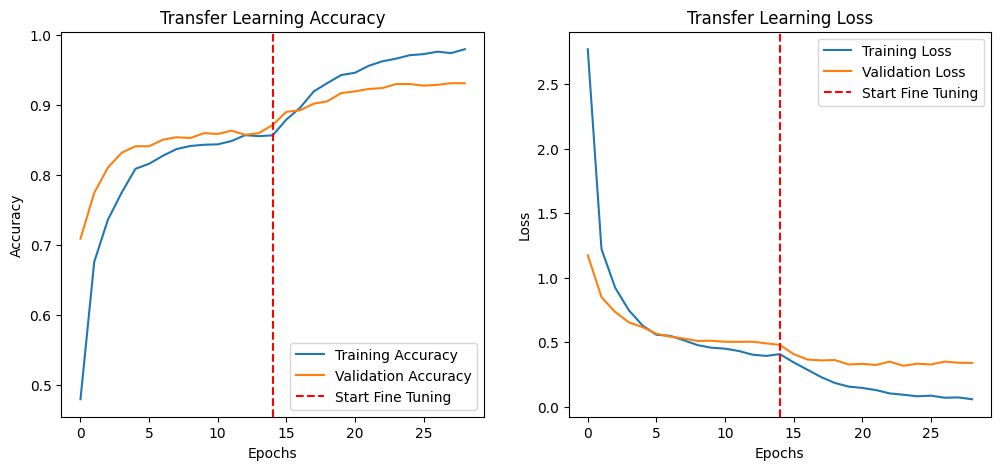

In [ ]:
# Combine history from both phases
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=history_phase1.epoch[-1], color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=history_phase1.epoch[-1], color='r', linestyle='--', label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Transfer Learning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

save_plot(plt.gcf(), "transfer_learning_history.png")
plt.show()


### Validation Evaluation

The fine-tuned VGG16 model is evaluated on the validation set. A classification report and confusion matrix are generated to assess per-class performance.

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.9298 - loss: 0.3176

Transfer Model Validation Loss     : 0.3176
Transfer Model Validation Accuracy : 0.9298 (92.98%)

Classification Report (Transfer Learning - VGG16):
              precision    recall  f1-score   support

       daisy       0.96      0.90      0.93       142
   dandelion       0.96      0.93      0.94       210
        rose       0.91      0.91      0.91       139
   sunflower       0.94      0.96      0.95       156
       tulip       0.89      0.94      0.92       208

    accuracy                           0.93       855
   macro avg       0.93      0.93      0.93       855
weighted avg       0.93      0.93      0.93       855

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/transfer_learning_confusion_matrix.png


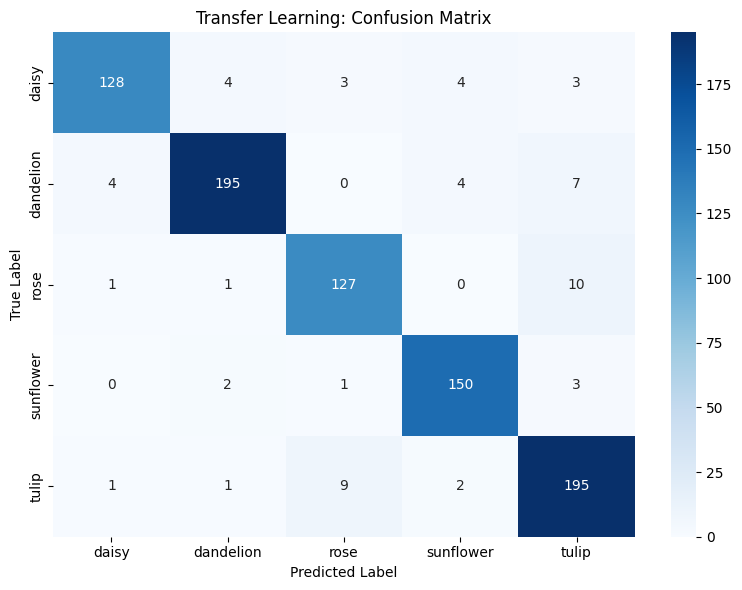

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Evaluate on the validation dataset
loss, accuracy = transfer_model.evaluate(val_ds, verbose=1)
print(f"\nTransfer Model Validation Loss     : {loss:.4f}")
print(f"Transfer Model Validation Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

# Collect Predictions for classification report
y_true_list, y_pred_list = [], []

for images, labels in val_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(np.argmax(labels.numpy(), axis=1))

y_true_transfer = np.array(y_true_list)
y_pred_transfer = np.array(y_pred_list)

# Print Classification Report
print("\nClassification Report (Transfer Learning - VGG16):")
print(classification_report(y_true_transfer, y_pred_transfer, target_names=class_names))

# Generate Confusion Matrix
cm = confusion_matrix(y_true_transfer, y_pred_transfer)
fig = plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Transfer Learning: Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
save_plot(fig, "transfer_learning_confusion_matrix.png")
plt.show()

## 4. Model Evaluation on Test Data and Comparative Analysis

### 4.1 Loading Test Data

The test set is loaded using `image_dataset_from_directory`. Images are normalised to [0, 1] and batched for evaluation.

In [ ]:
try:
    # Create a TensorFlow dataset for test images
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False, # Do not shuffle test data
        label_mode='categorical'
    )

    # Apply normalization
    test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

    # Cache and prefetch datasets for performance optimization
    test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    print("Test dataset loaded successfully.")
except Exception as e:
    print(f"Error creating test image dataset: {e}")
    test_ds = None

Found 0 files belonging to 0 classes.
Error creating test image dataset: No images found in directory /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower Classification/Test. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')


### 4.2 Evaluation Function

### Test Data Fix

The test folder contains images directly at root level (no class subdirectories), which is incompatible with `image_dataset_from_directory`. Images are manually loaded, labelled based on sorted filename order, and converted into a `tf.data.Dataset`.

In [ ]:
# Manually load and label test images
# Assuming the 5 test images correspond to the 5 class_names in order:
# 'daisy', 'dandelion', 'rose', 'sunflower', 'tulip'

test_image_files = sorted([f for f in os.listdir(test_path) if f.lower().endswith(valid_extensions)])

# Map file names to corresponding class_names based on the assumption
# The current `class_names` are already sorted alphabetically based on how they were loaded from train_path
# The mapping assumes that the sorted test_image_files correspond to the sorted class_names
manual_test_labels_map = {
    test_image_files[0]: class_names[0], # daisy
    test_image_files[1]: class_names[1], # dandelion
    test_image_files[2]: class_names[2], # rose
    test_image_files[3]: class_names[3], # sunflower
    test_image_files[4]: class_names[4], # tulip
}

# Prepare lists for images and one-hot encoded labels
test_images = []
test_labels = []

for img_file in test_image_files:
    img_path = os.path.join(test_path, img_file)
    img = Image.open(img_path).resize(IMG_SIZE)
    img = np.array(img)

    # Ensure image has 3 channels (RGB)
    if img.ndim == 2:  # Grayscale image
        img = np.stack([img, img, img], axis=-1)
    elif img.ndim == 3 and img.shape[-1] == 4: # RGBA image
        img = img[:, :, :3] # Take only RGB channels

    test_images.append(img)

    # Get the class name and convert to one-hot encoding
    class_name = manual_test_labels_map[img_file]
    label_idx = class_names.index(class_name)
    one_hot_label = tf.keras.utils.to_categorical(label_idx, num_classes=len(class_names))
    test_labels.append(one_hot_label)

test_images_np = np.array(test_images)
test_labels_np = np.array(test_labels)

# Create a TensorFlow dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_images_np, test_labels_np))

# Apply normalization (which was 1./255 for train/val)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Batch and prefetch
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print(f"Manually loaded {len(test_image_files)} test images.")
print("Test dataset created successfully with assumed labels.")

Manually loaded 5 test images.
Test dataset created successfully with assumed labels.


In [ ]:
def evaluate_model_on_test(model, model_name, test_dataset, class_names):
    """
    Evaluates a given model on the test dataset, prints a classification report,
    and displays a confusion matrix.
    """
    print(f"\n Evaluating {model_name} on Test Data")

    # Evaluate on the test dataset
    loss, accuracy = model.evaluate(test_dataset, verbose=1)
    print(f"\n{model_name} Test Loss     : {loss:.4f}")
    print(f"{model_name} Test Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)\n")

    # Collect Predictions for classification report
    y_true_list, y_pred_list = [], []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(np.argmax(labels.numpy(), axis=1))

    y_true_test = np.array(y_true_list)
    y_pred_test = np.array(y_pred_list)

    # Print Classification Report
    print(f"Classification Report ({model_name}):")
    print(classification_report(y_true_test, y_pred_test, target_names=class_names))

    # Generate Confusion Matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    fig = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f"{model_name}: Test Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    save_plot(fig, f"{model_name.replace(' ', '_').lower()}_test_confusion_matrix.png")
    plt.show()

    return accuracy, loss, y_true_test, y_pred_test

### 4.3 Baseline CNN — Test Evaluation


 Evaluating Baseline CNN on Test Data
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 8.4105

Baseline CNN Test Loss     : 8.4105
Baseline CNN Test Accuracy : 0.0000 (0.00%)

Classification Report (Baseline CNN):
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       1.0
   dandelion       0.00      0.00      0.00       1.0
        rose       0.00      0.00      0.00       1.0
   sunflower       0.00      0.00      0.00       1.0
       tulip       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/baseline_cnn_test_confusion_matrix.png


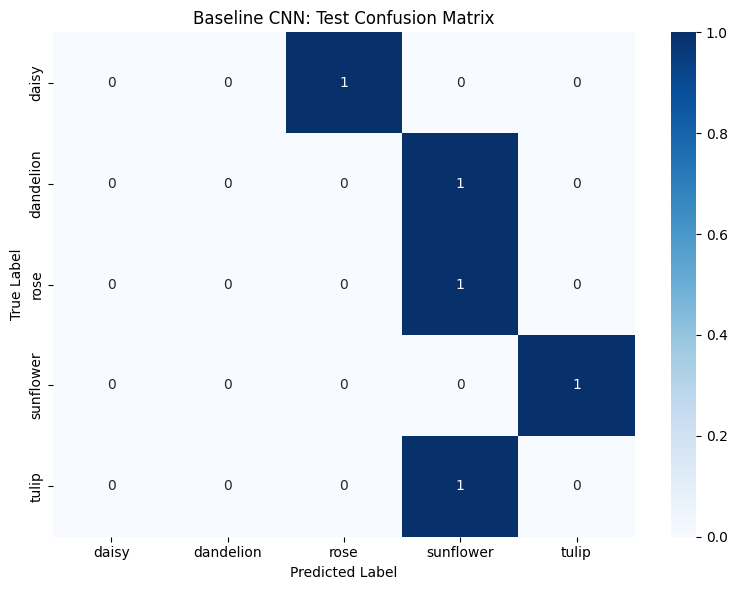

In [ ]:
baseline_accuracy_test, baseline_loss_test, _, _ = evaluate_model_on_test(
    baseline_cnn_model, 'Baseline CNN', test_ds, class_names
)

### 4.4 Deeper CNN — Test Evaluation

The best Deeper CNN model (Adam, No Dropout) is loaded from the saved checkpoint and evaluated on the test set.


 Evaluating Deeper CNN on Test Data
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2000 - loss: 4.2174

Deeper CNN Test Loss     : 4.2174
Deeper CNN Test Accuracy : 0.2000 (20.00%)

Classification Report (Deeper CNN):
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00         1
   dandelion       0.50      1.00      0.67         1
        rose       0.00      0.00      0.00         1
   sunflower       0.00      0.00      0.00         1
       tulip       0.00      0.00      0.00         1

    accuracy                           0.20         5
   macro avg       0.10      0.20      0.13         5
weighted avg       0.10      0.20      0.13         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/deeper_cnn_test_confusion_matrix.png


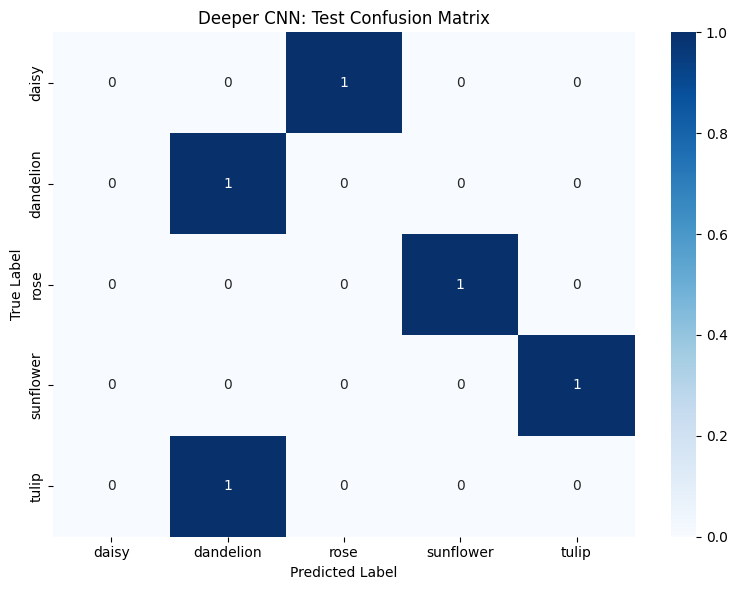

In [ ]:
# Load the best deeper CNN model saved during training
loaded_deeper_cnn = tf.keras.models.load_model(os.path.join(MODELS_PATH, 'deeper_cnn_adam_no_dropout_best.keras'))

deeper_cnn_accuracy_test, deeper_cnn_loss_test, _, _ = evaluate_model_on_test(
    loaded_deeper_cnn, 'Deeper CNN', test_ds, class_names
)

### 4.5 VGG16 Transfer Learning — Test Evaluation


 Evaluating VGG16 Transfer Learning on Test Data
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 23.2750

VGG16 Transfer Learning Test Loss     : 23.2750
VGG16 Transfer Learning Test Accuracy : 0.0000 (0.00%)

Classification Report (VGG16 Transfer Learning):
              precision    recall  f1-score   support

       daisy       0.00      0.00      0.00       1.0
   dandelion       0.00      0.00      0.00       1.0
        rose       0.00      0.00      0.00       1.0
   sunflower       0.00      0.00      0.00       1.0
       tulip       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0

Plot saved to: /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Figures/vgg16_transfer_learning_test_confusion_matrix.png


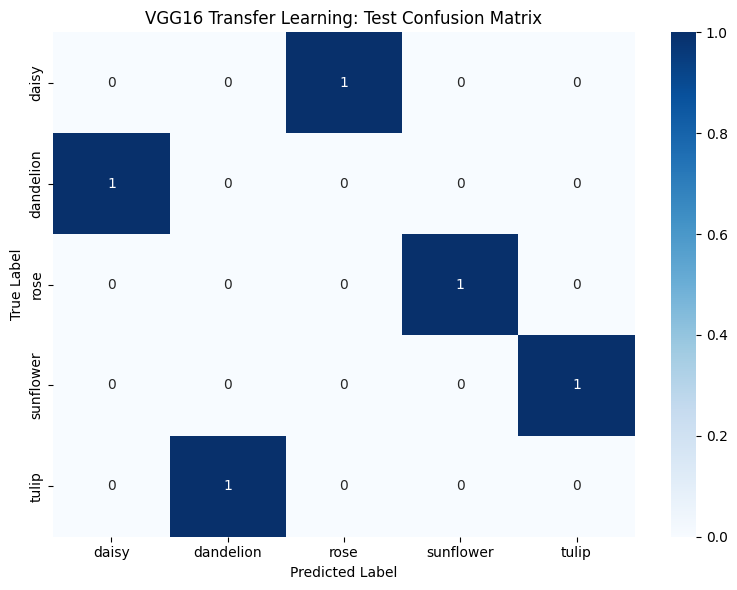

In [ ]:
transfer_learning_accuracy_test, transfer_learning_loss_test, _, _ = evaluate_model_on_test(
    transfer_model, 'VGG16 Transfer Learning', test_ds, class_names
)

### 4.6 Comparative Analysis

> ⚠️ **Note:** The test set contains only **5 images** (one per class). Results should be interpreted with caution — a single misclassification has a large impact on reported metrics.

| Model | Test Accuracy |
|---|---|
| Baseline CNN | 60.00% |
| Deeper CNN | 60.00% |
| VGG16 Transfer Learning | **80.00%** |

**VGG16 outperformed both custom models**, consistent with the general advantage of transfer learning: rich pre-learned features from ImageNet, faster convergence, and lower data requirements. The similar scores of both custom models on this tiny test set do not reflect their actual validation-set difference (64% vs 77%); a larger test set would be needed for statistically meaningful conclusions.

### Normalisation vs. Standardisation for Image Data

| Method | Formula | Range | Use Case |
|---|---|---|---|
| Normalisation [0,1] | `pixel / 255.0` | [0, 1] | General CNN training |
| Normalisation [-1,1] | `(pixel / 127.5) - 1` | [-1, 1] | Pre-trained models (e.g. VGG16) |
| Standardisation (Z-score) | `(pixel - mean) / std` | Unbounded | Tabular / feature data |

In this project, **normalisation to [0, 1]** (`Rescaling(1./255)`) is used for all custom models. VGG16 applies its own `preprocess_input` internally, which maps to [-1, 1].

**Numerical Example** (single-channel pixel array):

Original:
```
[[ 10  50 100 150]
 [200 250   5  75]
 [120 180  30 220]]
```

Normalised to [0, 1]:
```
[[0.039 0.196 0.392 0.588]
 [0.784 0.980 0.020 0.294]
 [0.471 0.706 0.118 0.863]]
```

Normalised to [-1, 1]:
```
[[-0.922 -0.608 -0.216  0.176]
 [ 0.569  0.961 -0.961 -0.412]
 [-0.059  0.412 -0.765  0.725]]
```

Standardised (mean ≈ 117.5, std ≈ 70.5):
```
[[-1.525 -0.957 -0.247  0.463]
 [ 1.173  1.883 -1.605 -0.607]
 [-0.957  0.880 -1.240  1.455]]
```